In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('train.csv')
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1


In [ ]:
df.shape

(593994, 13)

In [ ]:
df.describe().round(2)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.00,593994.00,593994.00,593994.00,593994.00,593994.00,593994.0
mean,296996.50,48212.20,0.12,680.92,15020.30,12.36,0.8
std,171471.44,26711.94,0.07,55.42,6926.53,2.01,0.4
min,0.00,6002.43,0.01,395.00,500.09,3.20,0.0
25%,148498.25,27934.40,0.07,646.00,10279.62,10.99,1.0
50%,296996.50,46557.68,0.10,682.00,15000.22,12.37,1.0
75%,445494.75,60981.32,0.16,719.00,18858.58,13.68,1.0
max,593993.00,393381.74,0.63,849.00,48959.95,20.99,1.0


In [ ]:
df.drop(columns=['id'], inplace=True)

In [ ]:
# List of columns to check
columns = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

# Print unique values for each column
for col in columns:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 50)

Unique values in 'gender':
['Female' 'Male' 'Other']
--------------------------------------------------
Unique values in 'marital_status':
['Single' 'Married' 'Divorced' 'Widowed']
--------------------------------------------------
Unique values in 'education_level':
['High School' "Master's" "Bachelor's" 'PhD' 'Other']
--------------------------------------------------
Unique values in 'employment_status':
['Self-employed' 'Employed' 'Unemployed' 'Retired' 'Student']
--------------------------------------------------
Unique values in 'loan_purpose':
['Other' 'Debt consolidation' 'Home' 'Education' 'Vacation' 'Car'
 'Medical' 'Business']
--------------------------------------------------
Unique values in 'grade_subgrade':
['C3' 'D3' 'C5' 'F1' 'D1' 'D5' 'C2' 'C1' 'F5' 'D4' 'C4' 'D2' 'E5' 'B1'
 'B2' 'F4' 'A4' 'E1' 'F2' 'B4' 'E4' 'B3' 'E3' 'B5' 'E2' 'F3' 'A5' 'A3'
 'A1' 'A2']
--------------------------------------------------


In [ ]:
df.isnull().sum()

annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 54.4+ MB


In [ ]:
# # Lists to store column names
# num = []
# cat = []

# # Loop through all columns
# for col in df.columns:
#     if df[col].dtype is  ['int64', 'float64']:
#         num.append(col)
#     else:
#         cat.append(col)

# print("Numeric columns:", num)
# print("Categorical columns:", cat)


In [ ]:
num = df.select_dtypes(include=['int64', 'float64']).columns
cat = df.select_dtypes(include=['object']).columns

print("Numeric columns:", num)
print("Categorical columns:", cat)

Numeric columns: Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')
Categorical columns: Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')


**EXPLORATORY DATA ANALYSIS**

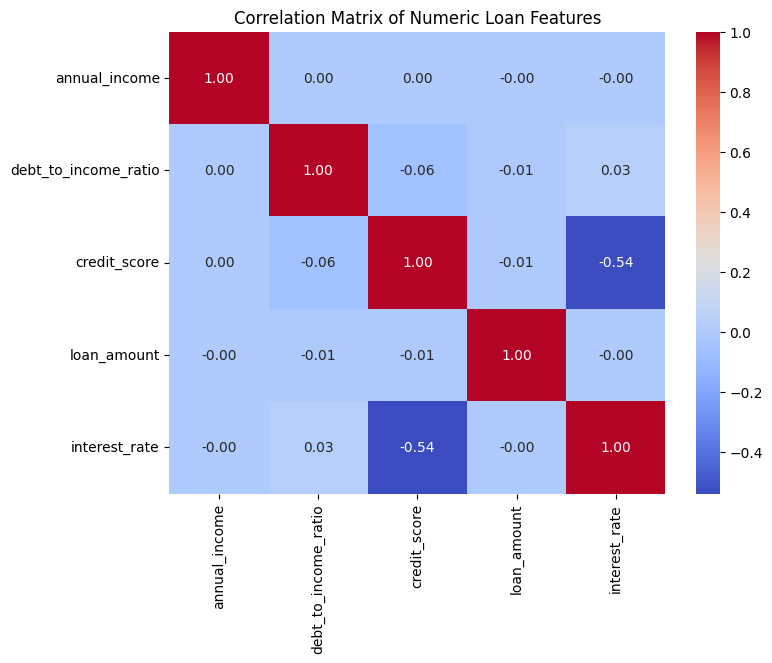

In [ ]:
# List of numeric columns
num = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

# Calculate correlation matrix
corr = df[num].corr()

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Loan Features")
plt.show()

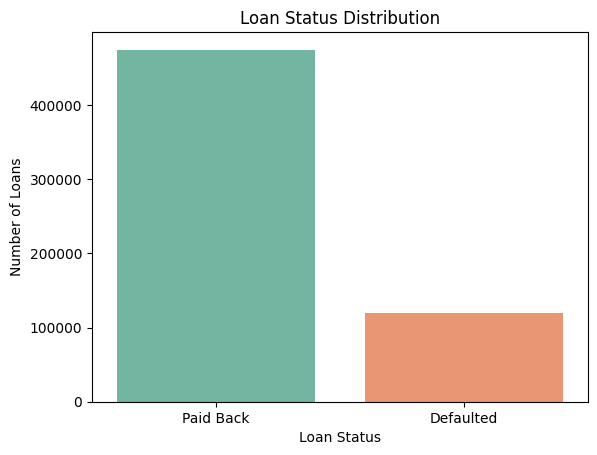

loan_status_label
Paid Back    474494
Defaulted    119500
Name: count, dtype: int64


In [ ]:
df['loan_status_label'] = df['loan_paid_back'].map({1: 'Paid Back', 0: 'Defaulted'})

# Plot the distribution
sns.countplot(x='loan_status_label', data=df, palette='Set2')
plt.title("Loan Status Distribution")
plt.ylabel("Number of Loans")
plt.xlabel("Loan Status")
plt.show()

# Print proportions
print(df['loan_status_label'].value_counts())


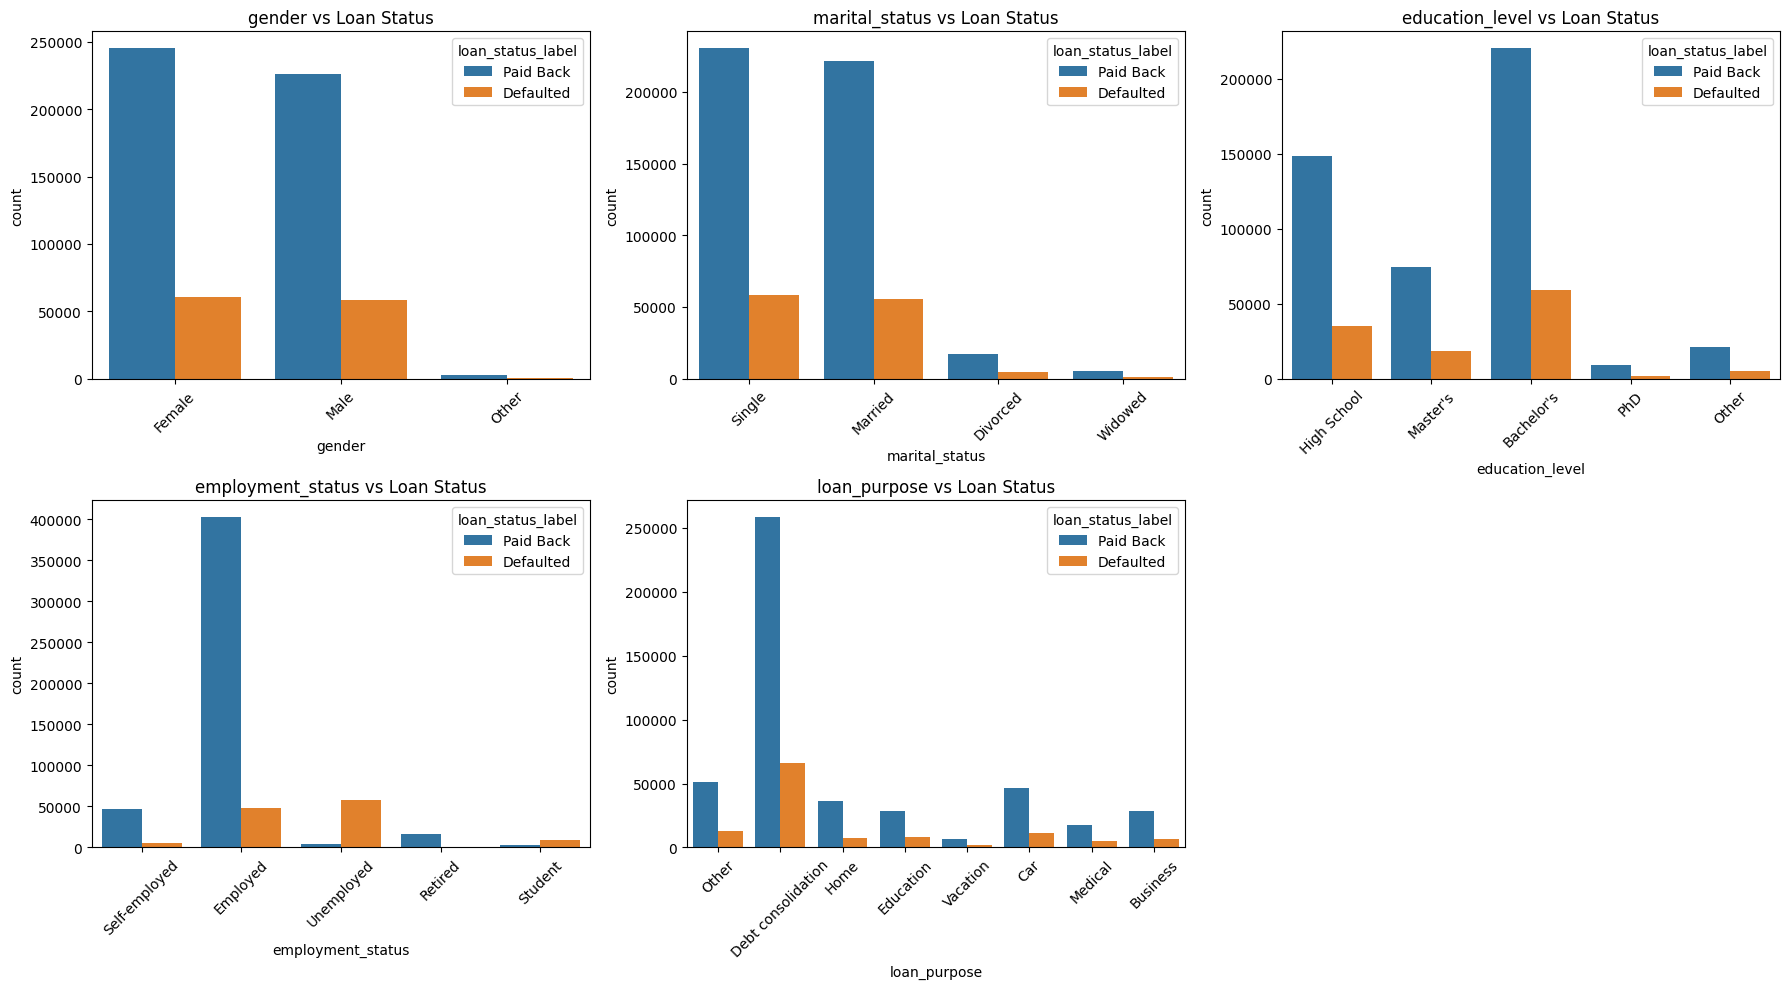

In [ ]:
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose']

# Create 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))


axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='loan_status_label', data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Loan Status")
    axes[i].tick_params(axis='x', rotation=45)


fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

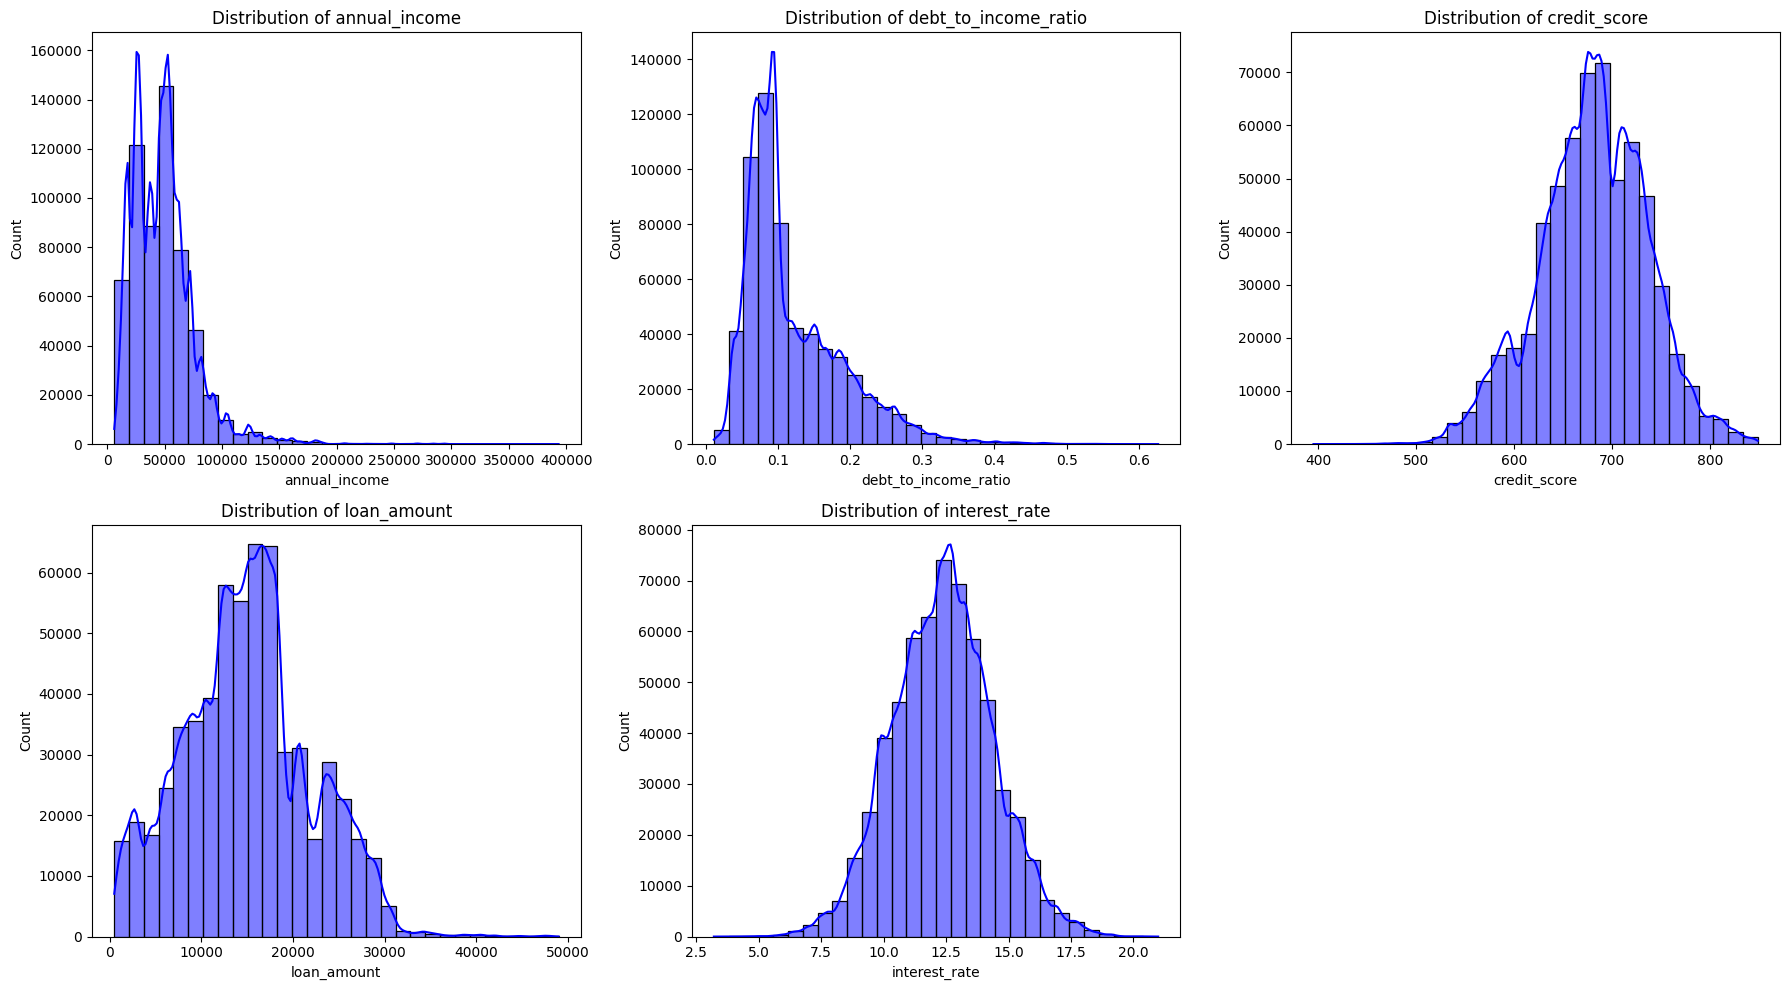

In [ ]:
num_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

# --- Histograms ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='blue', bins=30)
    axes[i].set_title(f"Distribution of {col}")

# Remove empty subplot (6th one)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

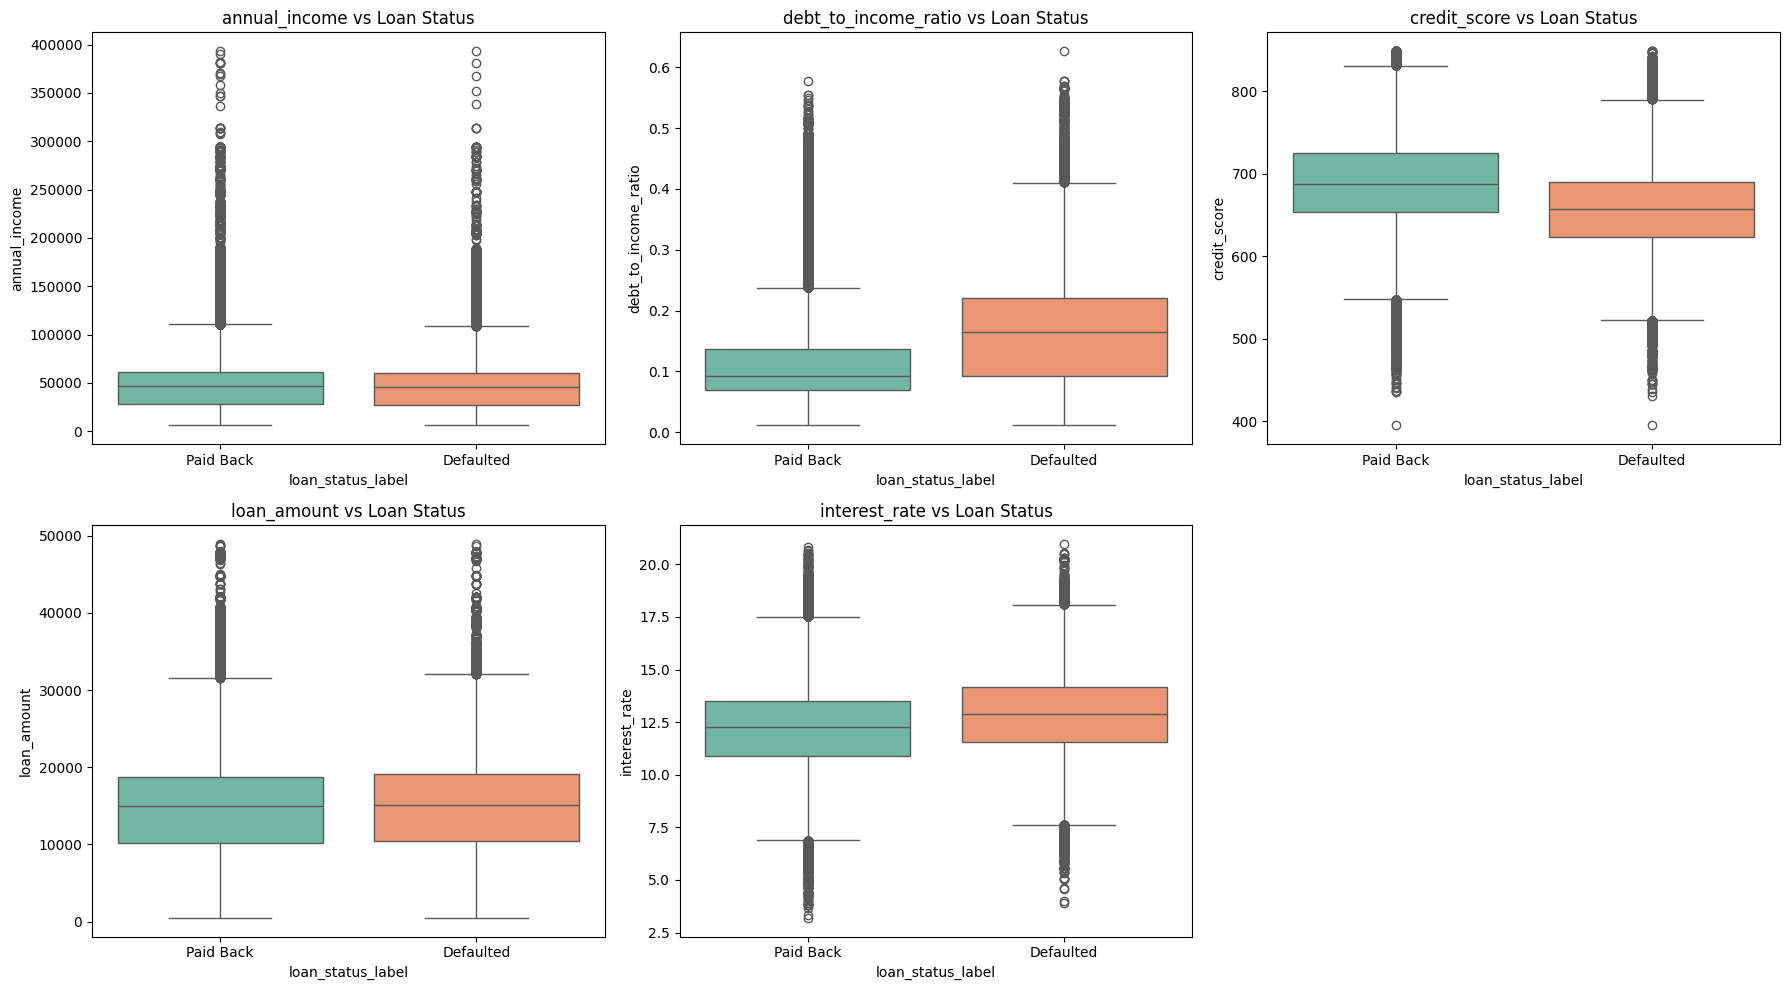

In [ ]:
# --- Boxplots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='loan_status_label', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f"{col} vs Loan Status")

# Remove empty subplot (6th one)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

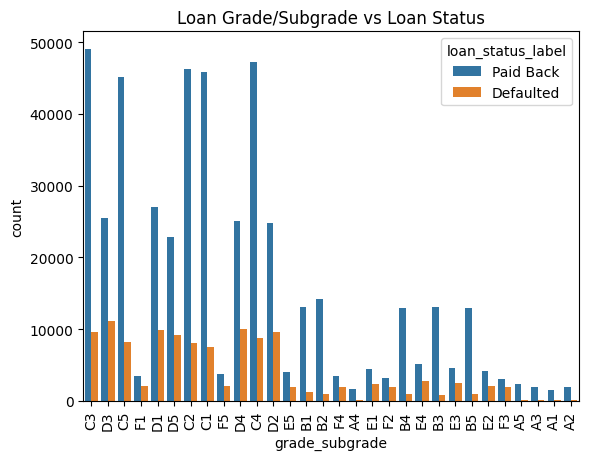

In [ ]:
sns.countplot(x='grade_subgrade', hue='loan_status_label', data=df)
plt.xticks(rotation=90)
plt.title("Loan Grade/Subgrade vs Loan Status")
plt.show()

**ENCODING**

In [ ]:
# Define the orders
edu_order = ['High School', "Bachelor's", "Master's", 'PhD', 'Other']
grade_order = ['A1','A2','A3','A4','A5',
               'B1','B2','B3','B4','B5',
               'C1','C2','C3','C4','C5',
               'D1','D2','D3','D4','D5',
               'E1','E2','E3','E4','E5',
               'F1','F2','F3','F4','F5']

# Create mapping dictionaries
edu_map = {level: i+1 for i, level in enumerate(edu_order)}
grade_map = {grade: i+1 for i, grade in enumerate(grade_order)}

# Map to new columns in the DataFrame
df['education_level_num'] = df['education_level'].map(edu_map)
df['grade_subgrade_num'] = df['grade_subgrade'].map(grade_map)


# One-Hot Encoding
onehot_cols = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)  # drop_first=True avoids dummy trap

In [ ]:
# Drop original categorical columns
df.drop(columns=['education_level','grade_subgrade','loan_status_label'], inplace=True)

# Rename numeric columns to original names (optional)
df.rename(columns={
    'education_level_num': 'education_level',
    'grade_subgrade_num': 'grade_subgrade'
}, inplace=True)

df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back,education_level,grade_subgrade,gender_Male,gender_Other,...,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
0,29367.99,0.084,736,2528.42,13.67,1,1,13,False,False,...,True,False,False,False,False,False,False,False,True,False
1,22108.02,0.166,636,4593.10,12.92,0,3,18,True,False,...,False,False,False,False,True,False,False,False,False,False
2,49566.20,0.097,694,17005.15,9.76,1,1,15,True,False,...,False,False,False,False,True,False,False,False,False,False
3,46858.25,0.065,533,4682.48,16.10,1,1,26,False,False,...,False,False,False,False,True,False,False,False,False,False
4,25496.70,0.053,665,12184.43,10.21,1,1,16,True,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Create Target Variable
# We want to predict 'Default' (Risk). Currently 0=Default, 1=Paid Back.
# Let's set the Target 'y' such that 1 = Default (Positive Class, Minority) and 0 = Paid Back (Negative Class, Majority).
# This makes metrics like Precision/Recall/F1 for Class 1 more meaningful for risk detection.

# Create 'default_target': 1 if loan_paid_back == 0, else 0
df['default_target'] = (df['loan_paid_back'] == 0).astype(int)

X = df.drop(columns=['loan_paid_back', 'default_target'])
y = df['default_target']

print("Target Distribution (1 = Default, 0 = Paid Back):")
print(y.value_counts())

Target Distribution (1 = Default, 0 = Paid Back):
default_target
0    474494
1    119500
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Calculate Scale_Pos_Weight for XGBoost
# Since we flipped the labels (1=Default, 0=Paid Back), we are dealing with an imbalanced dataset where 1 is the Minority.
# scale_pos_weight = sum(negative instances) / sum(positive instances)
# This weights the positive class (1) more heavily.

count_neg = (y_train == 0).sum() # Majority (Paid Back)
count_pos = (y_train == 1).sum() # Minority (Default)

ratio = count_neg / count_pos

print(f"Majority (Paid Back): {count_neg}")
print(f"Minority (Default): {count_pos}")
print(f"scale_pos_weight ratio: {ratio:.4f}")

Majority (Paid Back): 379595
Minority (Default): 95600
scale_pos_weight ratio: 3.9707


In [ ]:
models = {
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=ratio),
    'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
}

# Cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV and collect results
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name} Average CV Accuracy: {scores.mean():.4f}")

# Find best model
best_model_name = max(cv_results, key=cv_results.get)
print("\nBest Model Based on CV Accuracy:", best_model_name)

XGBoost Average CV Accuracy: 0.8670
RandomForest Average CV Accuracy: 0.9014


In [ ]:
y.value_counts()

,count
loan_paid_back,
1,474494
0,119500


In [ ]:
 pip install scikit-optimize

In [ ]:
from skopt import BayesSearchCV

In [ ]:
# Define XGBoost classifier
xgb = XGBClassifier(
    scale_pos_weight=ratio,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=1,
    tree_method='hist'
)

# Hyperparameter search space
xgb_search_space = {
    'n_estimators': (100, 500),
    'max_depth': (3, 15),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'subsample': (0.5, 1.0, 'uniform'),
    'colsample_bytree': (0.5, 1.0, 'uniform'),
    'gamma': (0, 5),
    'reg_alpha': (1e-3, 10, 'log-uniform'),
    'reg_lambda': (1e-3, 10, 'log-uniform')
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Bayesian Optimization with Accuracy
opt_xgb = BayesSearchCV(
    estimator=xgb,
    search_spaces=xgb_search_space,
    n_iter=20,
    scoring='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

# Fit model
opt_xgb.fit(X_train, y_train)

# Output results
print("Best XGBoost Parameters:", opt_xgb.best_params_)
print("Best CV Accuracy:", opt_xgb.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
best_xgb_model = opt_xgb.best_estimator_

### Model Evaluation
Now that we have the best model from the optimization, let's evaluate its performance on both the training and test sets.
We will look at Accuracy, but also Precision, Recall, and F1-score which are crucial for imbalanced datasets like loan default prediction.
- **Precision**: Of all loans predicted as Default, how many actually defaulted?
- **Recall**: Of all actual Defaults, how many did we catch?

In [ ]:
# Predictions
y_pred_train = best_xgb_model.predict(X_train)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)

# Print results
print("XGBoost Classification Performance:")
print(f"Train Accuracy: {acc_train:.4f}")

XGBoost Classification Performance:
Train Accuracy: 0.9236


In [ ]:
y_pred_test = best_xgb_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
print(f"Train Accuracy: {acc_test:.4f}")

Train Accuracy: 0.9005


In [ ]:
# Define Random Forest model
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
rf_search_space = {
    'n_estimators': (100, 400),
    'max_depth': (3, 20),
    'min_samples_split': (2, 10),
}

# Bayesian Optimization with Stratified CV
opt_rf = BayesSearchCV(
    estimator=rf,
    search_spaces=rf_search_space,
    n_iter=5,
    scoring='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
# Fit model
opt_rf.fit(X_train, y_train)

# Best model
best_rf = opt_rf.best_estimator_

# Output results
print("Best Random Forest Parameters:", opt_rf.best_params_)
print("Best CV Accuracy:", opt_rf.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Random Forest Parameters: OrderedDict({'max_depth': 19, 'min_samples_split': 8, 'n_estimators': 361})
Best CV Accuracy: 0.8810509369837647


In [ ]:
# Best model
best_rf = opt_rf.best_estimator_

# Predictions
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

# Output results
print("Random Forest Results")
print("---------------------")
print(f"Train Accuracy  : {acc_train:.4f}")
print(f"Test Accuracy   : {acc_test:.4f}")

Random Forest Results
---------------------
Train Accuracy  : 0.9045
Test Accuracy   : 0.8801


In [ ]:
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))


Classification Report (Train):
              precision    recall  f1-score   support

           0       0.74      0.81      0.77     95600
           1       0.95      0.93      0.94    379595

    accuracy                           0.90    475195
   macro avg       0.85      0.87      0.86    475195
weighted avg       0.91      0.90      0.91    475195


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.69      0.74      0.71     23900
           1       0.93      0.91      0.92     94899

    accuracy                           0.88    118799
   macro avg       0.81      0.83      0.82    118799
weighted avg       0.88      0.88      0.88    118799



In [ ]:
X.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'education_level', 'grade_subgrade', 'gender_Male',
       'gender_Other', 'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'employment_status_Retired',
       'employment_status_Self-employed', 'employment_status_Student',
       'employment_status_Unemployed', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation'],
      dtype='object')

In [ ]:
import joblib

joblib.dump(best_xgb_model,'XGBClassifier.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'feature_names.pkl')

['feature_names.pkl']

In [ ]:
import xgboost
print(xgboost.__version__)

3.1.3


In [ ]:
# # Feature importance (no saving)
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# 1) locate the RF model (prefer in-memory variables)
rf = None
try:
    rf = best_rf
except NameError:
    try:
        rf = opt_rf.best_estimator_
    except Exception:
        rf = None

if rf is None:
    raise RuntimeError("Random Forest model not found in-memory (`best_rf` or `opt_rf`).")

# 2) get importances
if hasattr(rf, "feature_importances_"):
    importances = np.array(rf.feature_importances_)
elif hasattr(rf, "coef_"):
    importances = np.abs(np.array(rf.coef_)).ravel()
else:
    raise RuntimeError("Model has no `feature_importances_` or `coef_` attribute.")

# 3) feature names (use the original DataFrame `X`)
try:
    feature_names = X.columns.tolist()
except Exception:
    feature_names = [f"f{i}" for i in range(len(importances))]

# 4) build dataframe and plot top 20
fi = pd.DataFrame({"feature": feature_names, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(20).iloc[::-1]

plt.figure(figsize=(8, max(4, 0.25 * len(fi))))
plt.barh(fi["feature"], fi["importance"], color="C2")
plt.title("Random Forest — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()